In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [2]:
DATA_PATH = Path("../data/synthetic/wafer_manufacturing.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (2500, 15)

Columns:
['wafer_id', 'lot_id', 'wafer_number', 'product_id', 'equipment_id', 'chamber_id', 'temperature', 'pressure', 'rf_power', 'gas_flow', 'etch_time', 'process_anomaly', 'defect_type', 'defect_count', 'yield_percent']


In [3]:
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   wafer_id         2500 non-null   str    
 1   lot_id           2500 non-null   str    
 2   wafer_number     2500 non-null   int64  
 3   product_id       2500 non-null   str    
 4   equipment_id     2500 non-null   str    
 5   chamber_id       2500 non-null   str    
 6   temperature      2500 non-null   float64
 7   pressure         2500 non-null   float64
 8   rf_power         2500 non-null   float64
 9   gas_flow         2500 non-null   float64
 10  etch_time        2500 non-null   float64
 11  process_anomaly  2500 non-null   int64  
 12  defect_type      2500 non-null   str    
 13  defect_count     2500 non-null   int64  
 14  yield_percent    2500 non-null   float64
dtypes: float64(6), int64(3), str(6)
memory usage: 293.1 KB


,wafer_number,temperature,pressure,rf_power,gas_flow,etch_time,process_anomaly,defect_count,yield_percent
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,13.000000,300.722950,1.213064,853.594928,49.976535,59.904363,0.050000,2.012400,97.379252
std,7.212545,6.006966,0.096024,46.746983,3.071448,3.919286,0.217989,2.845538,2.449581
min,1.000000,283.683666,0.908127,726.687794,40.569001,42.443542,0.000000,0.000000,81.172397
25%,7.000000,296.760675,1.150159,823.423595,47.940748,57.388695,0.000000,0.000000,96.682633
50%,13.000000,300.319895,1.204128,851.920066,49.950550,59.826832,0.000000,1.000000,97.946567
75%,19.000000,303.937647,1.262626,879.871521,52.022293,62.377302,0.000000,2.000000,98.896250
max,25.000000,331.081075,1.654475,1066.382795,62.077472,73.743710,1.000000,21.000000,100.000000


In [4]:
missing = df.isnull().sum()

print("Missing values:")
print(missing)

Missing values:
wafer_id           0
lot_id             0
wafer_number       0
product_id         0
equipment_id       0
chamber_id         0
temperature        0
pressure           0
rf_power           0
gas_flow           0
etch_time          0
process_anomaly    0
defect_type        0
defect_count       0
yield_percent      0
dtype: int64


In [5]:
print("Number of lots:", df["lot_id"].nunique())
print("Number of wafers:", df["wafer_id"].nunique())

print("\nWafers per lot:")
print(df.groupby("lot_id")["wafer_id"].count().describe())

Number of lots: 100
Number of wafers: 2500

Wafers per lot:
count    100.0
mean      25.0
std        0.0
min       25.0
25%       25.0
50%       25.0
75%       25.0
max       25.0
Name: wafer_id, dtype: float64


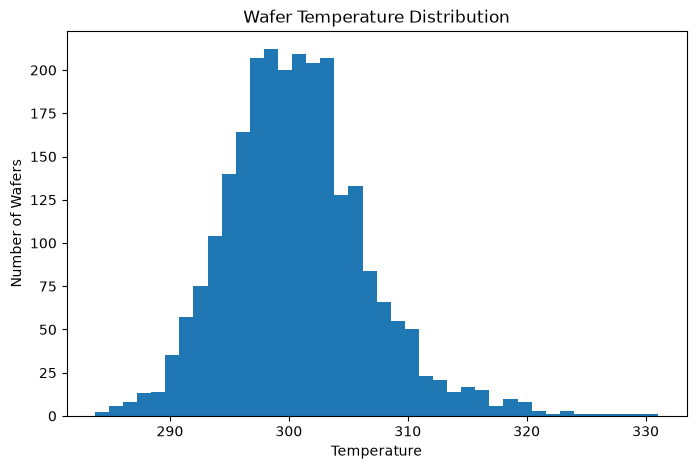

In [6]:
plt.figure(figsize=(8, 5))

plt.hist(df["temperature"], bins=40)

plt.xlabel("Temperature")
plt.ylabel("Number of Wafers")
plt.title("Wafer Temperature Distribution")

plt.show()

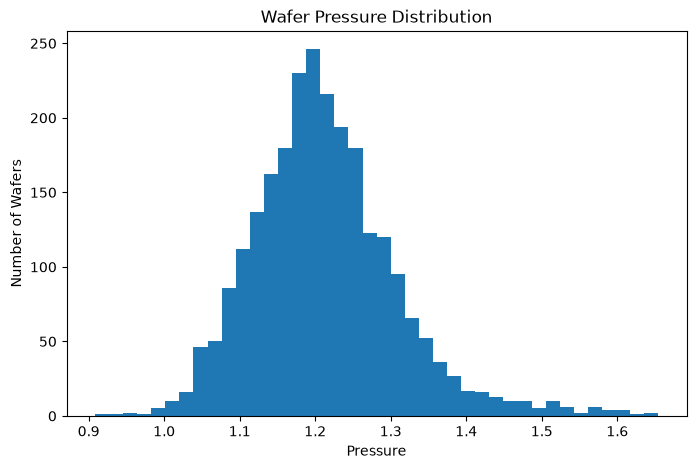

In [7]:
plt.figure(figsize=(8, 5))

plt.hist(df["pressure"], bins=40)

plt.xlabel("Pressure")
plt.ylabel("Number of Wafers")
plt.title("Wafer Pressure Distribution")

plt.show()

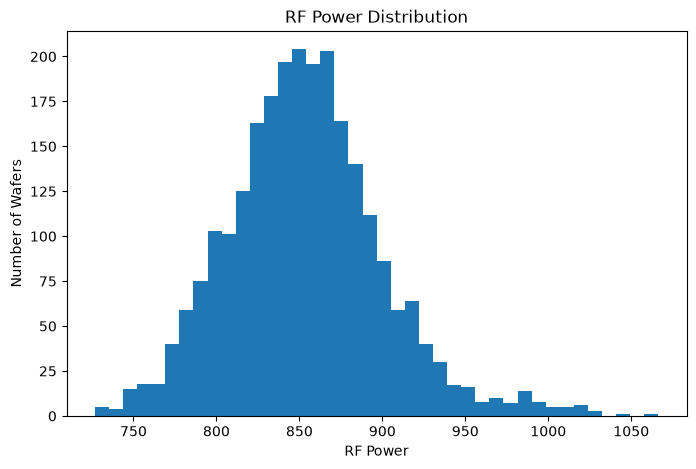

In [8]:
plt.figure(figsize=(8, 5))

plt.hist(df["rf_power"], bins=40)

plt.xlabel("RF Power")
plt.ylabel("Number of Wafers")
plt.title("RF Power Distribution")

plt.show()

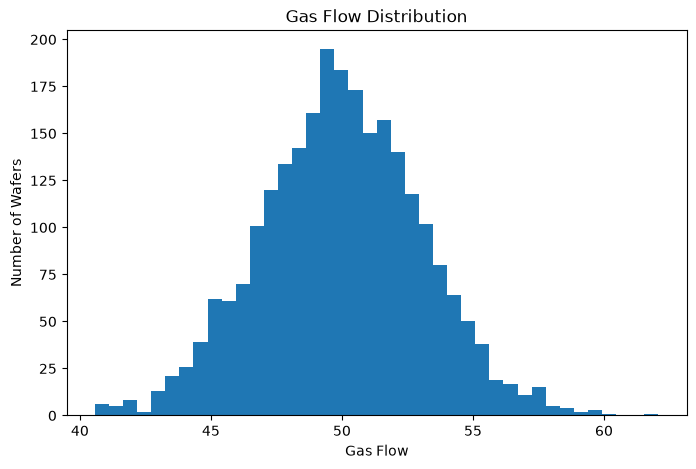

In [9]:
plt.figure(figsize=(8, 5))

plt.hist(df["gas_flow"], bins=40)

plt.xlabel("Gas Flow")
plt.ylabel("Number of Wafers")
plt.title("Gas Flow Distribution")

plt.show()

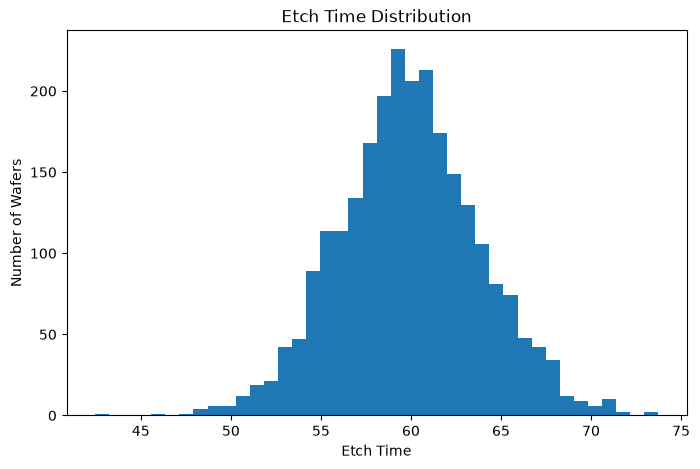

In [10]:
plt.figure(figsize=(8, 5))

plt.hist(df["etch_time"], bins=40)

plt.xlabel("Etch Time")
plt.ylabel("Number of Wafers")
plt.title("Etch Time Distribution")

plt.show()

defect_type
Particle     534
Edge-Ring    504
Random       494
Center       487
Scratch      481
Name: count, dtype: int64


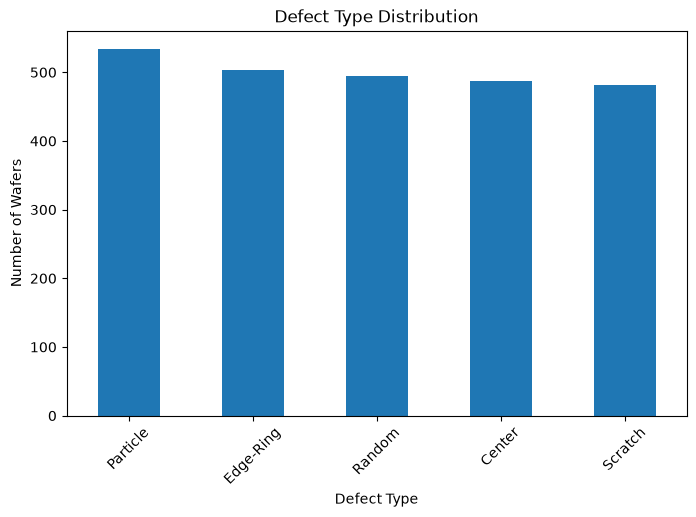

In [11]:
defect_counts = df["defect_type"].value_counts()

print(defect_counts)
plt.figure(figsize=(8, 5))

defect_counts.plot(kind="bar")

plt.xlabel("Defect Type")
plt.ylabel("Number of Wafers")
plt.title("Defect Type Distribution")

plt.xticks(rotation=45)

plt.show()

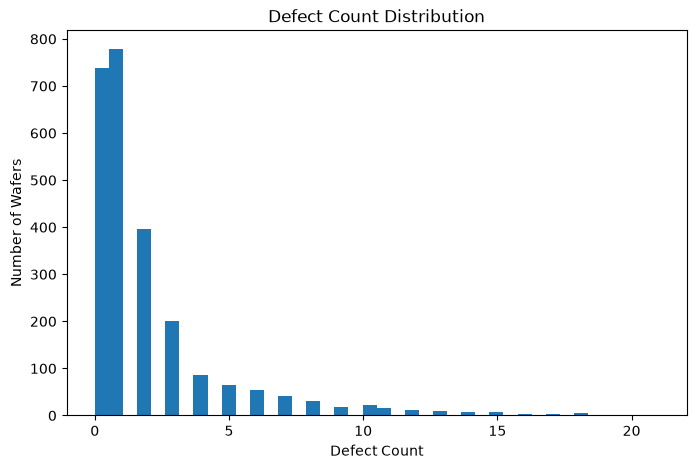

In [12]:
plt.figure(figsize=(8, 5))

plt.hist(df["defect_count"], bins=40)

plt.xlabel("Defect Count")
plt.ylabel("Number of Wafers")
plt.title("Defect Count Distribution")

plt.show()

count    2500.000000
mean       97.379252
std         2.449581
min        81.172397
25%        96.682633
50%        97.946567
75%        98.896250
max       100.000000
Name: yield_percent, dtype: float64


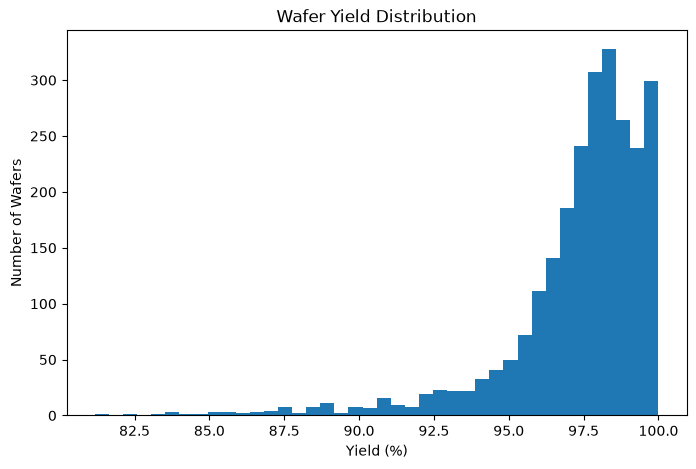

In [13]:
print(df["yield_percent"].describe())
plt.figure(figsize=(8, 5))

plt.hist(df["yield_percent"], bins=40)

plt.xlabel("Yield (%)")
plt.ylabel("Number of Wafers")
plt.title("Wafer Yield Distribution")

plt.show()

In [14]:
df.groupby("process_anomaly")[
    ["temperature", "pressure", "rf_power",
     "gas_flow", "etch_time", "defect_count", "yield_percent"]
].mean()

,temperature,pressure,rf_power,gas_flow,etch_time,defect_count,yield_percent
process_anomaly,,,,,,,
0,300.012234,1.200981,848.093631,49.986220,59.891389,1.559579,97.742111
1,314.226565,1.442643,958.119570,49.792519,60.150862,10.616000,90.484924


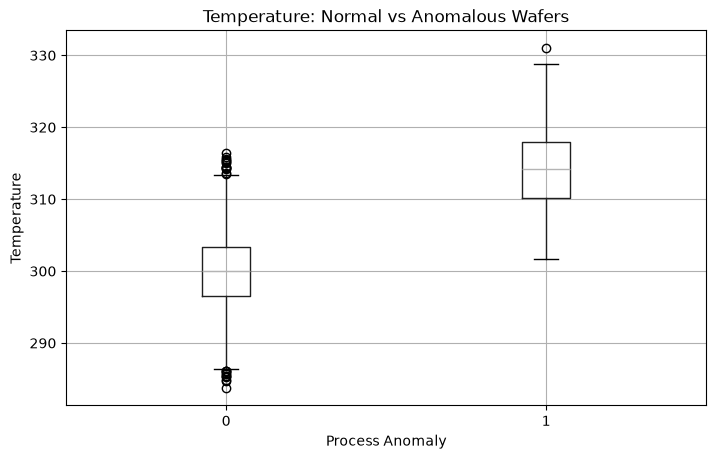

In [15]:
df.boxplot(
    column="temperature",
    by="process_anomaly",
    figsize=(8, 5)
)

plt.title("Temperature: Normal vs Anomalous Wafers")
plt.suptitle("")
plt.xlabel("Process Anomaly")
plt.ylabel("Temperature")

plt.show()

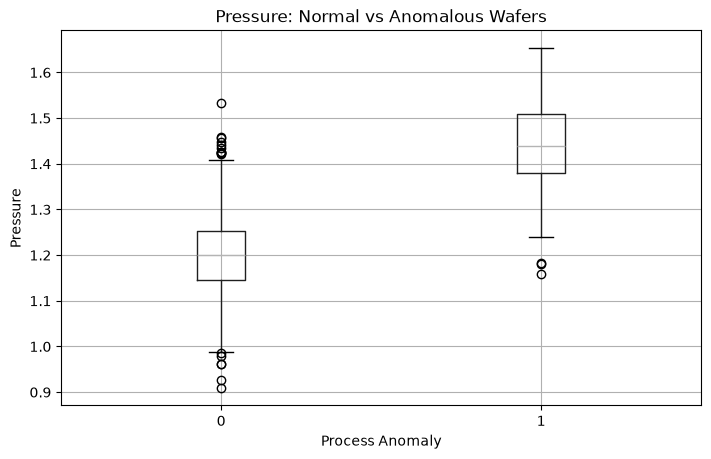

In [16]:
df.boxplot(
    column="pressure",
    by="process_anomaly",
    figsize=(8, 5)
)

plt.title("Pressure: Normal vs Anomalous Wafers")
plt.suptitle("")
plt.xlabel("Process Anomaly")
plt.ylabel("Pressure")

plt.show()

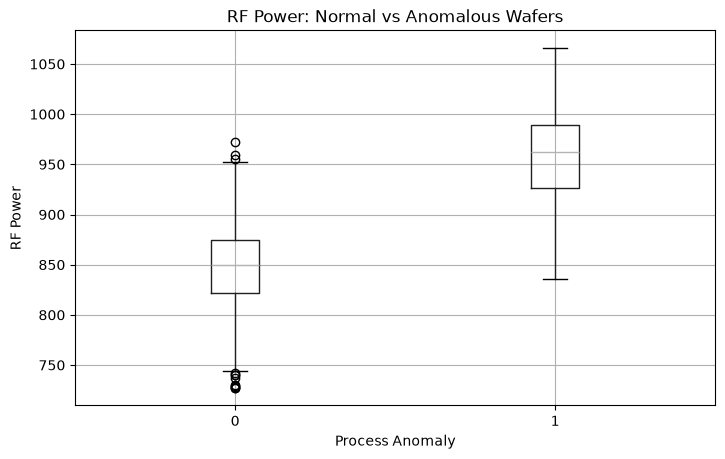

In [17]:
df.boxplot(
    column="rf_power",
    by="process_anomaly",
    figsize=(8, 5)
)

plt.title("RF Power: Normal vs Anomalous Wafers")
plt.suptitle("")
plt.xlabel("Process Anomaly")
plt.ylabel("RF Power")

plt.show()

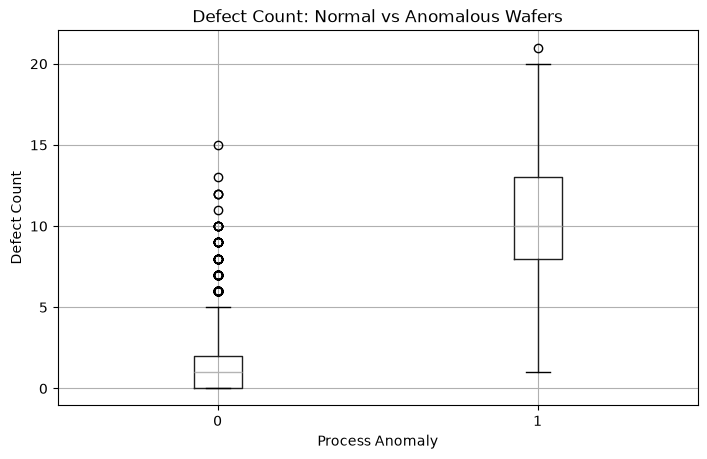

In [18]:
df.boxplot(
    column="defect_count",
    by="process_anomaly",
    figsize=(8, 5)
)

plt.title("Defect Count: Normal vs Anomalous Wafers")
plt.suptitle("")
plt.xlabel("Process Anomaly")
plt.ylabel("Defect Count")

plt.show()

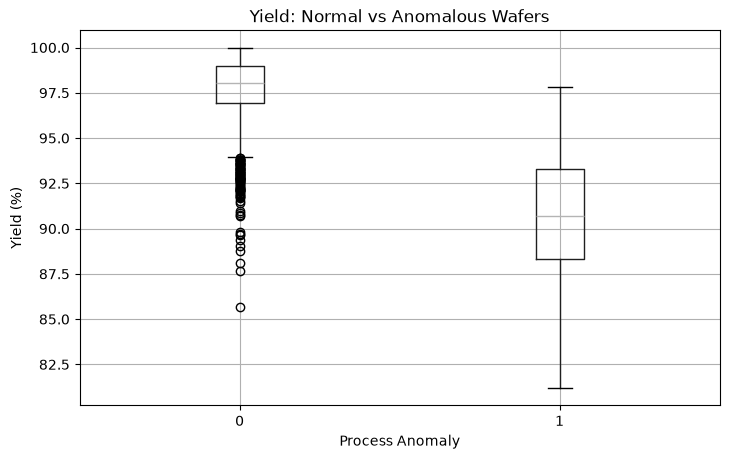

In [19]:
df.boxplot(
    column="yield_percent",
    by="process_anomaly",
    figsize=(8, 5)
)

plt.title("Yield: Normal vs Anomalous Wafers")
plt.suptitle("")
plt.xlabel("Process Anomaly")
plt.ylabel("Yield (%)")

plt.show()

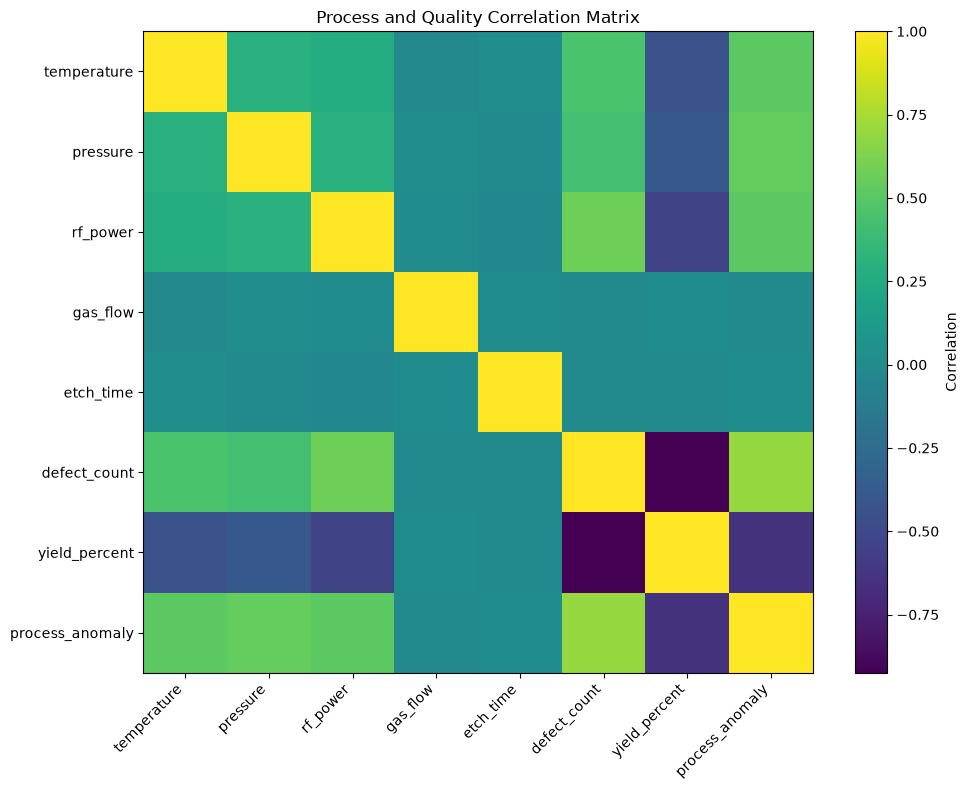

In [20]:
numeric_columns = [
    "temperature",
    "pressure",
    "rf_power",
    "gas_flow",
    "etch_time",
    "defect_count",
    "yield_percent",
    "process_anomaly"
]

correlation = df[numeric_columns].corr()

correlation
plt.figure(figsize=(10, 8))

plt.imshow(correlation, aspect="auto")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.colorbar(label="Correlation")

plt.title("Process and Quality Correlation Matrix")

plt.tight_layout()
plt.show()

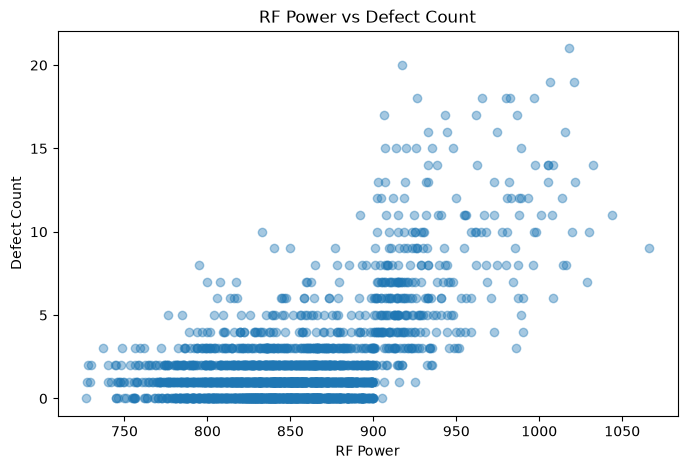

In [21]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["rf_power"],
    df["defect_count"],
    alpha=0.4
)

plt.xlabel("RF Power")
plt.ylabel("Defect Count")
plt.title("RF Power vs Defect Count")

plt.show()

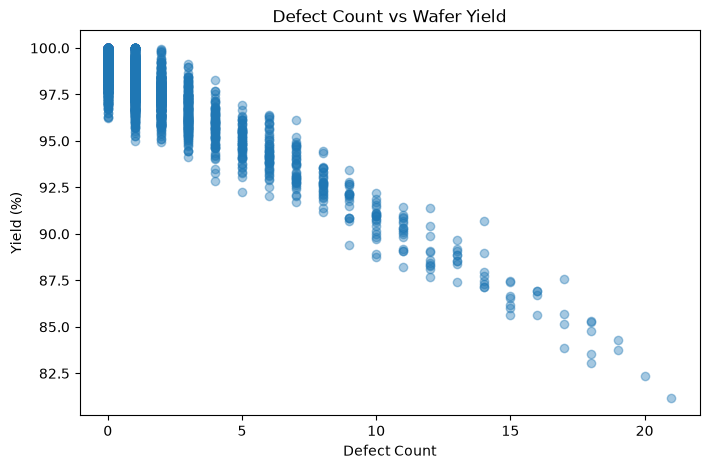

In [22]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["defect_count"],
    df["yield_percent"],
    alpha=0.4
)

plt.xlabel("Defect Count")
plt.ylabel("Yield (%)")
plt.title("Defect Count vs Wafer Yield")

plt.show()

In [23]:
lot_summary = (
    df.groupby("lot_id")
      .agg(
          wafer_count=("wafer_id", "count"),
          avg_defects=("defect_count", "mean"),
          avg_yield=("yield_percent", "mean"),
          anomaly_wafers=("process_anomaly", "sum")
      )
      .reset_index()
)

lot_summary.head(10)
lot_summary.sort_values(
    "avg_defects",
    ascending=False
).head(10)
lot_summary.sort_values(
    "avg_yield"
).head(10)


,lot_id,wafer_count,avg_defects,avg_yield,anomaly_wafers
87,L0088,25,3.68,95.977709,4
41,L0042,25,3.48,96.083146,3
38,L0039,25,2.96,96.518609,5
83,L0084,25,3.12,96.598964,2
76,L0077,25,2.76,96.663496,2
99,L0100,25,2.80,96.667859,1
3,L0004,25,2.48,96.673249,2
28,L0029,25,2.72,96.674481,2
6,L0007,25,2.80,96.686753,1
91,L0092,25,2.80,96.721173,2


In [24]:
lot_summary.sort_values(
    "anomaly_wafers",
    ascending=False
).head(10)

,lot_id,wafer_count,avg_defects,avg_yield,anomaly_wafers
84,L0085,25,3.00,96.803810,5
38,L0039,25,2.96,96.518609,5
87,L0088,25,3.68,95.977709,4
21,L0022,25,2.84,96.767615,3
37,L0038,25,1.92,97.575820,3
41,L0042,25,3.48,96.083146,3
73,L0074,25,2.60,97.159645,3
78,L0079,25,2.68,96.937470,3
12,L0013,25,2.60,97.132723,3
22,L0023,25,1.96,97.480030,3


In [25]:
OUTPUT_PATH = Path("../data/processed/lot_summary.csv")

lot_summary.to_csv(
    OUTPUT_PATH,
    index=False
)

print(f"Saved: {OUTPUT_PATH}")


Saved: ..\data\processed\lot_summary.csv


In [26]:
df.groupby("process_anomaly")[
    ["temperature", "pressure", "rf_power",
     "gas_flow", "etch_time", "defect_count", "yield_percent"]
].mean()

,temperature,pressure,rf_power,gas_flow,etch_time,defect_count,yield_percent
process_anomaly,,,,,,,
0,300.012234,1.200981,848.093631,49.986220,59.891389,1.559579,97.742111
1,314.226565,1.442643,958.119570,49.792519,60.150862,10.616000,90.484924


In [27]:
correlation

,temperature,pressure,rf_power,gas_flow,etch_time,defect_count,yield_percent,process_anomaly
temperature,1.000000,0.296499,0.266944,-0.018656,0.017737,0.455704,-0.429812,0.515828
pressure,0.296499,1.000000,0.298985,0.020789,-0.002998,0.428057,-0.393951,0.548612
rf_power,0.266944,0.298985,1.000000,0.005235,-0.024210,0.572797,-0.530811,0.513068
gas_flow,-0.018656,0.020789,0.005235,1.000000,0.009116,-0.005912,0.012273,-0.013747
etch_time,0.017737,-0.002998,-0.024210,0.009116,1.000000,-0.001474,-0.010999,0.014432
defect_count,0.455704,0.428057,0.572797,-0.005912,-0.001474,1.000000,-0.924273,0.693787
yield_percent,-0.429812,-0.393951,-0.530811,0.012273,-0.010999,-0.924273,1.000000,-0.645818
process_anomaly,0.515828,0.548612,0.513068,-0.013747,0.014432,0.693787,-0.645818,1.000000


In [29]:
anomaly_df = pd.read_csv(
    "../data/processed/anomaly_results.csv"
)

anomaly_df.groupby("anomaly_prediction")[
    [
        "temperature",
        "pressure",
        "rf_power",
        "gas_flow",
        "etch_time",
        "defect_count",
        "yield_percent",
    ]
].mean()
top_anomalies = anomaly_df.sort_values(
    "anomaly_score",
    ascending=False
)

top_anomalies[
    [
        "wafer_id",
        "lot_id",
        "temperature",
        "pressure",
        "rf_power",
        "gas_flow",
        "etch_time",
        "defect_count",
        "yield_percent",
        "process_anomaly",
        "anomaly_score",
    ]
].head(20)

,wafer_id,lot_id,temperature,pressure,rf_power,gas_flow,etch_time,defect_count,yield_percent,process_anomaly,anomaly_score
2025,L0082_W01,L0082,328.105144,1.463808,1017.966117,55.350455,57.045123,21,81.172397,1,0.123279
1437,L0058_W13,L0058,328.843034,1.435998,1007.866212,55.090075,55.908200,11,91.434642,1,0.118404
759,L0031_W10,L0031,324.550903,1.528698,932.693374,53.923747,52.119940,16,85.623094,1,0.117329
1060,L0043_W11,L0043,325.892537,1.453396,987.772696,47.388959,67.031066,12,88.420978,1,0.117224
2317,L0093_W18,L0093,316.567188,1.611239,1043.537823,52.236918,64.351975,11,90.847910,1,0.113594
469,L0019_W20,L0019,313.543936,1.514888,1066.382795,49.633748,51.229826,9,90.869186,1,0.110663
893,L0036_W19,L0036,315.008922,1.484649,989.080611,41.562959,55.989048,15,86.178646,1,0.108070
2380,L0096_W06,L0096,323.780950,1.505873,891.653235,50.322736,70.444305,11,89.995497,1,0.106381
1044,L0042_W20,L0042,319.965246,1.619398,1008.007961,50.921325,59.737477,14,87.965503,1,0.106292
566,L0023_W17,L0023,321.029460,1.604843,961.898505,54.635696,59.217511,8,93.555915,1,0.105697


In [31]:
evaluation_df = anomaly_df.copy()

evaluation_df["detection_category"] = "Unknown"

evaluation_df.loc[
    (evaluation_df["process_anomaly"] == 0) &
    (evaluation_df["anomaly_prediction"] == 0),
    "detection_category"
] = "True Negative"

evaluation_df.loc[
    (evaluation_df["process_anomaly"] == 0) &
    (evaluation_df["anomaly_prediction"] == 1),
    "detection_category"
] = "False Positive"

evaluation_df.loc[
    (evaluation_df["process_anomaly"] == 1) &
    (evaluation_df["anomaly_prediction"] == 0),
    "detection_category"
] = "False Negative"

evaluation_df.loc[
    (evaluation_df["process_anomaly"] == 1) &
    (evaluation_df["anomaly_prediction"] == 1),
    "detection_category"
] = "True Positive"

evaluation_df["detection_category"].value_counts()



false_positives = evaluation_df[
    evaluation_df["detection_category"] == "False Positive"
].sort_values(
    "anomaly_score",
    ascending=False
)

false_positives[
    [
        "wafer_id",
        "lot_id",
        "temperature",
        "pressure",
        "rf_power",
        "gas_flow",
        "etch_time",
        "defect_count",
        "yield_percent",
        "anomaly_score",
    ]
].head(20)


false_negatives = evaluation_df[
    evaluation_df["detection_category"] == "False Negative"
].sort_values(
    "anomaly_score",
    ascending=False
)

false_negatives[
    [
        "wafer_id",
        "lot_id",
        "temperature",
        "pressure",
        "rf_power",
        "gas_flow",
        "etch_time",
        "defect_count",
        "yield_percent",
        "anomaly_score",
    ]
].head(20)




,wafer_id,lot_id,temperature,pressure,rf_power,gas_flow,etch_time,defect_count,yield_percent,anomaly_score
1720,L0069_W21,L0069,318.870742,1.158191,878.098082,49.992976,67.881960,3,95.290578,-0.000570
1300,L0053_W01,L0053,310.186723,1.371338,993.245700,48.576756,56.651865,12,88.601531,-0.000619
1762,L0071_W13,L0071,316.173424,1.339811,979.776108,51.092123,59.668595,8,92.612046,-0.001295
1528,L0062_W04,L0062,315.490973,1.404437,935.495324,45.350463,59.357515,15,86.659010,-0.004916
289,L0012_W15,L0012,314.455402,1.498690,925.397625,50.962549,60.954403,15,87.397255,-0.005644
1580,L0064_W06,L0064,315.820280,1.379350,955.534160,52.646593,60.860417,6,94.127217,-0.006165
1963,L0079_W14,L0079,315.872826,1.474097,914.768068,51.568159,58.974685,11,90.338412,-0.007954
707,L0029_W08,L0029,316.247608,1.361135,944.307335,46.361844,61.709924,8,92.074237,-0.009009
1299,L0052_W25,L0052,315.736641,1.378266,961.863855,47.641142,60.384229,10,91.060461,-0.012748
1457,L0059_W08,L0059,317.136351,1.401947,907.771741,53.236505,60.445540,11,89.055314,-0.012831
